<a href="https://colab.research.google.com/github/Prince2720/ecommerce-sales-analysis/blob/main/ecommerce_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Sales & Consumer Behaviour Analysis
**Dataset:** Olist Brazilian E-Commerce (Kaggle) — 100,000+ orders | 2016–2018  
**Tools:** Python, Pandas, Matplotlib, Seaborn, SQL (via pandasql)  
**Author:** Sarvesh Kumar Shukla

---
## Objectives
- Identify top revenue-driving product categories
- Analyze seasonal demand patterns
- Understand regional performance across Brazilian states
- Calculate Customer Lifetime Value (CLV) and Repeat Purchase Rate
- Perform RFM segmentation to classify customers
- Extract Month-over-Month revenue growth


## Step 1 — Install & Import Libraries

In [1]:
!pip install pandasql -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandasql as ps
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('All libraries loaded successfully!')

  Preparing metadata (setup.py) ... done
All libraries loaded successfully!


## Step 2 — Upload Dataset Files
Run this cell to upload your CSV files from your computer.

In [14]:
from google.colab import files

print('Upload these 8 CSV files from your brazilian_ecommerce folder:')
print('1. olist_orders_dataset.csv')
print('2. olist_order_items_dataset.csv')
print('3. olist_customers_dataset.csv')
print('4. olist_products_dataset.csv')
print('5. olist_order_payments_dataset.csv')
print('6. olist_order_reviews_dataset.csv')
print('7. olist_sellers_dataset.csv')
print('8. product_category_name_translation.csv')

uploaded = files.upload()

Upload these 8 CSV files from your brazilian_ecommerce folder:
1. olist_orders_dataset.csv
2. olist_order_items_dataset.csv
3. olist_customers_dataset.csv
4. olist_products_dataset.csv
5. olist_order_payments_dataset.csv
6. olist_order_reviews_dataset.csv
7. olist_sellers_dataset.csv
8. product_category_name_translation.csv


Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset (1).csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset (1).csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset (1).csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset (1).csv
Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv
Saving olist_products_dataset.csv to olist_products_dataset (1).csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset (1).csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


## Step 3 — Load Data into DataFrames

In [16]:
orders       = pd.read_csv('olist_orders_dataset (1).csv', parse_dates=[
                    'order_purchase_timestamp','order_approved_at',
                    'order_delivered_customer_date','order_estimated_delivery_date'])
order_items  = pd.read_csv('olist_order_items_dataset (1).csv')
customers    = pd.read_csv('olist_customers_dataset (1).csv')
products     = pd.read_csv('olist_products_dataset (1).csv')
payments     = pd.read_csv('olist_order_payments_dataset (1).csv')
reviews      = pd.read_csv('olist_order_reviews_dataset (1).csv')
sellers      = pd.read_csv('olist_sellers_dataset (1).csv')
cat_trans    = pd.read_csv('product_category_name_translation.csv')

print('Dataset loaded successfully!')
print(f'Orders       : {orders.shape}')
print(f'Order Items  : {order_items.shape}')
print(f'Customers    : {customers.shape}')
print(f'Products     : {products.shape}')
print(f'Payments     : {payments.shape}')
print(f'Reviews      : {reviews.shape}')
print(f'Sellers      : {sellers.shape}')
print(f'Category Translation : {cat_trans.shape}')

Dataset loaded successfully!
Orders       : (99441, 8)
Order Items  : (112650, 7)
Customers    : (99441, 5)
Products     : (32951, 9)
Payments     : (103886, 5)
Reviews      : (99224, 7)
Sellers      : (3095, 4)
Category Translation : (71, 2)


## Step 4 — Data Cleaning & Merging

In [17]:
# Filter delivered orders only
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Merge all tables
df = (delivered
      .merge(order_items,  on='order_id',   how='left')
      .merge(customers,    on='customer_id', how='left')
      .merge(products,     on='product_id',  how='left')
      .merge(cat_trans,    on='product_category_name', how='left'))

# Feature engineering
df['total_price']     = df['price'] + df['freight_value']
df['order_month']     = df['order_purchase_timestamp'].dt.to_period('M')
df['order_year']      = df['order_purchase_timestamp'].dt.year
df['order_month_num'] = df['order_purchase_timestamp'].dt.month

print(f'Merged dataset shape : {df.shape}')
print(f'Date range           : {df["order_purchase_timestamp"].min().date()} to {df["order_purchase_timestamp"].max().date()}')
print(f'Null values in key columns:')
print(df[['price','freight_value','product_category_name_english','customer_state']].isnull().sum())

Merged dataset shape : (110197, 31)
Date range           : 2016-09-15 to 2018-08-29
Null values in key columns:
price                               0
freight_value                       0
product_category_name_english    1559
customer_state                      0
dtype: int64


## Step 5 — KPI Summary

In [18]:
total_revenue    = df['price'].sum()
total_orders     = df['order_id'].nunique()
unique_customers = df['customer_unique_id'].nunique()
avg_order_value  = df.groupby('order_id')['price'].sum().mean()
avg_review       = reviews['review_score'].mean()

kpis = pd.DataFrame({
    'KPI'  : ['Total Revenue (BRL)', 'Total Orders', 'Unique Customers', 'Avg Order Value (BRL)', 'Avg Review Score'],
    'Value': [f'R$ {total_revenue:,.2f}', f'{total_orders:,}', f'{unique_customers:,}',
              f'R$ {avg_order_value:,.2f}', f'{avg_review:.2f} / 5']
})
print('='*45)
print('           KPI SUMMARY DASHBOARD')
print('='*45)
print(kpis.to_string(index=False))
print('='*45)

           KPI SUMMARY DASHBOARD
                  KPI            Value
  Total Revenue (BRL) R$ 13,221,498.11
         Total Orders           96,478
     Unique Customers           93,358
Avg Order Value (BRL)        R$ 137.04
     Avg Review Score         4.09 / 5


## Step 6 — Monthly Revenue Trend (Seasonality)

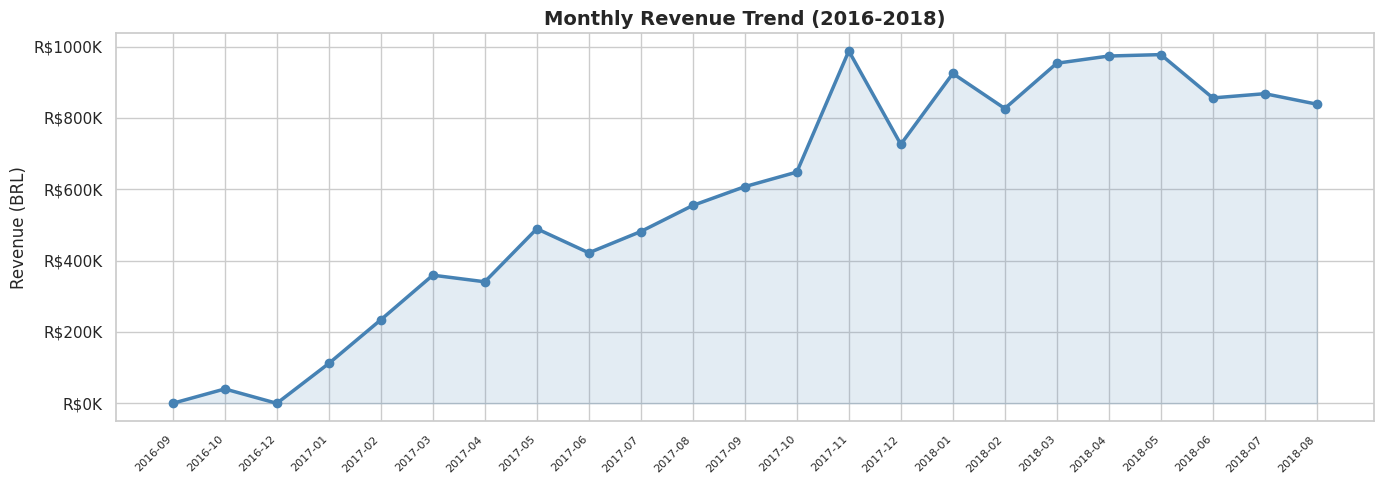

Peak month: 2017-11 | Revenue: R$ 987,765


In [19]:
monthly = (df.groupby('order_month')['price']
             .sum().reset_index()
             .rename(columns={'price':'revenue'}))
monthly['order_month'] = monthly['order_month'].astype(str)
monthly['mom_growth']  = monthly['revenue'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.fill_between(range(len(monthly)), monthly['revenue'], alpha=0.15, color='steelblue')
ax1.plot(range(len(monthly)), monthly['revenue'], marker='o', linewidth=2.5, color='steelblue', label='Revenue')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['order_month'], rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax1.set_title('Monthly Revenue Trend (2016-2018)', fontweight='bold')
ax1.set_ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Peak month:', monthly.loc[monthly['revenue'].idxmax(), 'order_month'],
      '| Revenue: R$', f"{monthly['revenue'].max():,.0f}")

## Step 7 — Top 10 Product Categories by Revenue

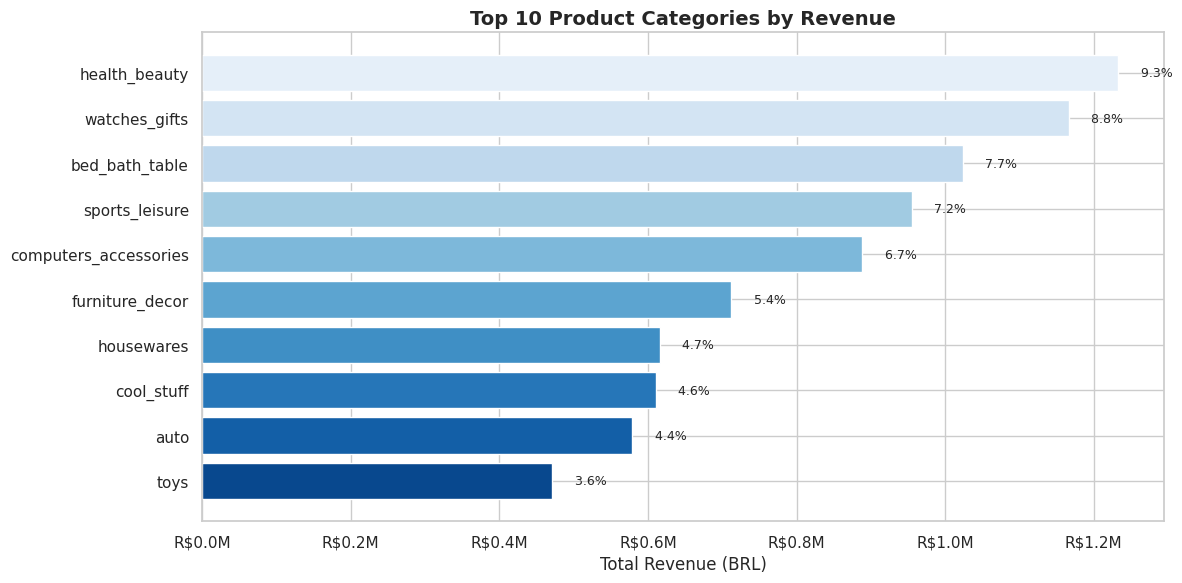

Top 3 categories: ['health_beauty', 'watches_gifts', 'bed_bath_table']
Combined revenue share: 25.9% of total sales


In [20]:
cat_rev = (df.groupby('product_category_name_english')['price']
             .sum().sort_values(ascending=False)
             .head(10).reset_index())
cat_rev.columns = ['category', 'revenue']
cat_rev['revenue_pct'] = (cat_rev['revenue'] / df['price'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_rev['category'][::-1], cat_rev['revenue'][::-1],
               color=sns.color_palette('Blues_r', 10))
for i, (rev, pct) in enumerate(zip(cat_rev['revenue'][::-1], cat_rev['revenue_pct'][::-1])):
    ax.text(rev + 20000, i, f'  {pct:.1f}%', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Top 10 Product Categories by Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

top3_pct = cat_rev['revenue_pct'].head(3).sum()
print(f'Top 3 categories: {cat_rev["category"].head(3).tolist()}')
print(f'Combined revenue share: {top3_pct:.1f}% of total sales')

## Step 8 — Revenue by State (Regional Performance)

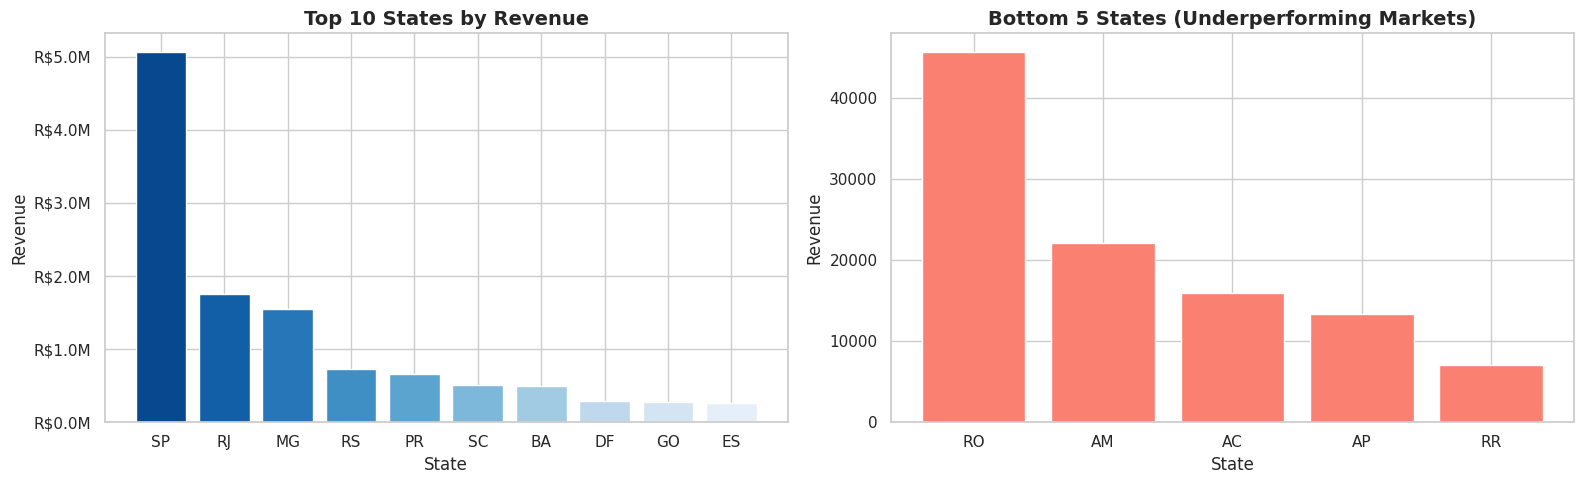

Top 5 states:
customer_state  total_revenue  total_orders
            SP     5067633.16         40501
            RJ     1759651.13         12350
            MG     1552481.83         11354
            RS      728897.47          5345
            PR      666063.51          4923

Bottom 5 states (underperforming):
customer_state  total_revenue  total_orders
            RO       45682.76           243
            AM       22155.84           145
            AC       15930.97            80
            AP       13374.81            67
            RR        7057.47            41


In [21]:
state_rev = (df.groupby('customer_state')
               .agg(total_revenue=('price','sum'), total_orders=('order_id','nunique'))
               .sort_values('total_revenue', ascending=False).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 states
top10 = state_rev.head(10)
axes[0].bar(top10['customer_state'], top10['total_revenue'],
            color=sns.color_palette('Blues_r', 10))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
axes[0].set_title('Top 10 States by Revenue', fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Revenue')

# Bottom 5 states (underperforming)
bottom5 = state_rev.tail(5)
axes[1].bar(bottom5['customer_state'], bottom5['total_revenue'], color='salmon')
axes[1].set_title('Bottom 5 States (Underperforming Markets)', fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('revenue_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 states:')
print(state_rev.head(5).to_string(index=False))
print('\nBottom 5 states (underperforming):')
print(state_rev.tail(5).to_string(index=False))

## Step 9 — Customer Repeat Purchase Rate & CLV

Repeat Purchase Rate : 3.00%
One-Time Buyers      : 97.00%

Average CLV          : R$ 141.62
Max CLV              : R$ 13,440.00


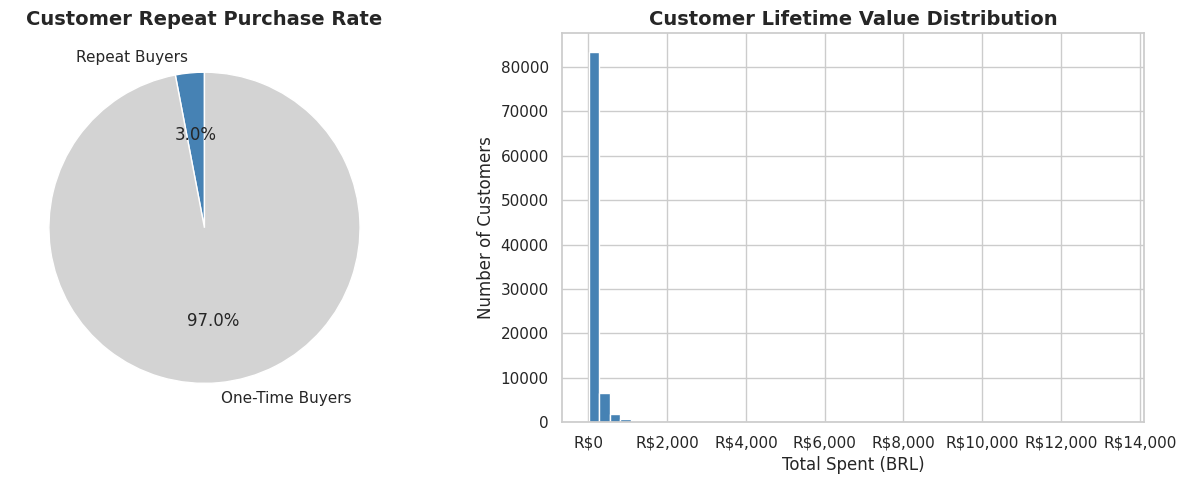

In [22]:
# Repeat purchase rate
cust_orders = (orders[orders['order_status']=='delivered']
               .merge(customers, on='customer_id')
               .groupby('customer_unique_id')['order_id']
               .nunique().reset_index()
               .rename(columns={'order_id':'order_count'}))

repeat_rate = (cust_orders['order_count'] > 1).mean() * 100
print(f'Repeat Purchase Rate : {repeat_rate:.2f}%')
print(f'One-Time Buyers      : {100 - repeat_rate:.2f}%')

# CLV
clv = (df.groupby('customer_unique_id')
         .agg(total_spent=('price','sum'), total_orders=('order_id','nunique'))
         .reset_index())
print(f'\nAverage CLV          : R$ {clv["total_spent"].mean():,.2f}')
print(f'Max CLV              : R$ {clv["total_spent"].max():,.2f}')

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([repeat_rate, 100-repeat_rate],
            labels=['Repeat Buyers', 'One-Time Buyers'],
            autopct='%1.1f%%', colors=['steelblue','lightgray'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Customer Repeat Purchase Rate', fontweight='bold')

axes[1].hist(clv['total_spent'], bins=50, color='steelblue', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
axes[1].set_title('Customer Lifetime Value Distribution', fontweight='bold')
axes[1].set_xlabel('Total Spent (BRL)')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('clv_repeat_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — RFM Customer Segmentation

RFM Customer Segmentation Summary:
            segment  num_customers  avg_clv  total_revenue
    Loyal Customers          48925   149.03     7291136.58
          Champions          15064   259.44     3908230.33
Potential Loyalists          23341    76.87     1794241.66
            At Risk           6028    37.81      227889.54


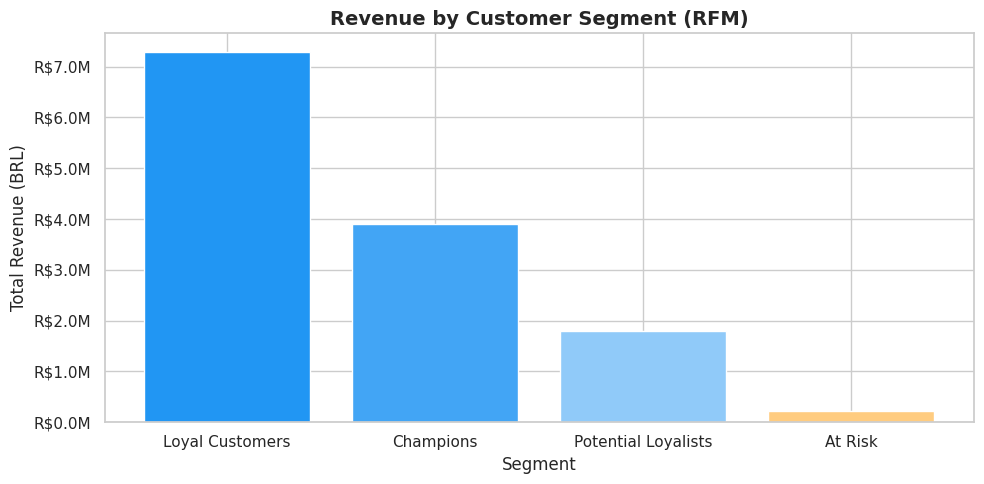

In [23]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (df.groupby('customer_unique_id').agg(
    recency  = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency= ('order_id', 'nunique'),
    monetary = ('price', 'sum')
).reset_index())

rfm['r_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal Customers'
    elif score >= 5: return 'Potential Loyalists'
    elif score >= 3: return 'At Risk'
    else: return 'Lost Customers'

rfm['segment'] = rfm['rfm_total'].apply(segment)

seg_summary = (rfm.groupby('segment')
                  .agg(num_customers=('customer_unique_id','count'),
                       avg_clv=('monetary','mean'),
                       total_revenue=('monetary','sum'))
                  .sort_values('total_revenue', ascending=False)
                  .reset_index())
seg_summary['avg_clv']       = seg_summary['avg_clv'].round(2)
seg_summary['total_revenue'] = seg_summary['total_revenue'].round(2)

print('RFM Customer Segmentation Summary:')
print(seg_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3','#42A5F5','#90CAF9','#FFCC80','#EF9A9A']
ax.bar(seg_summary['segment'], seg_summary['total_revenue'], color=colors)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Revenue by Customer Segment (RFM)', fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Month-over-Month Revenue Growth

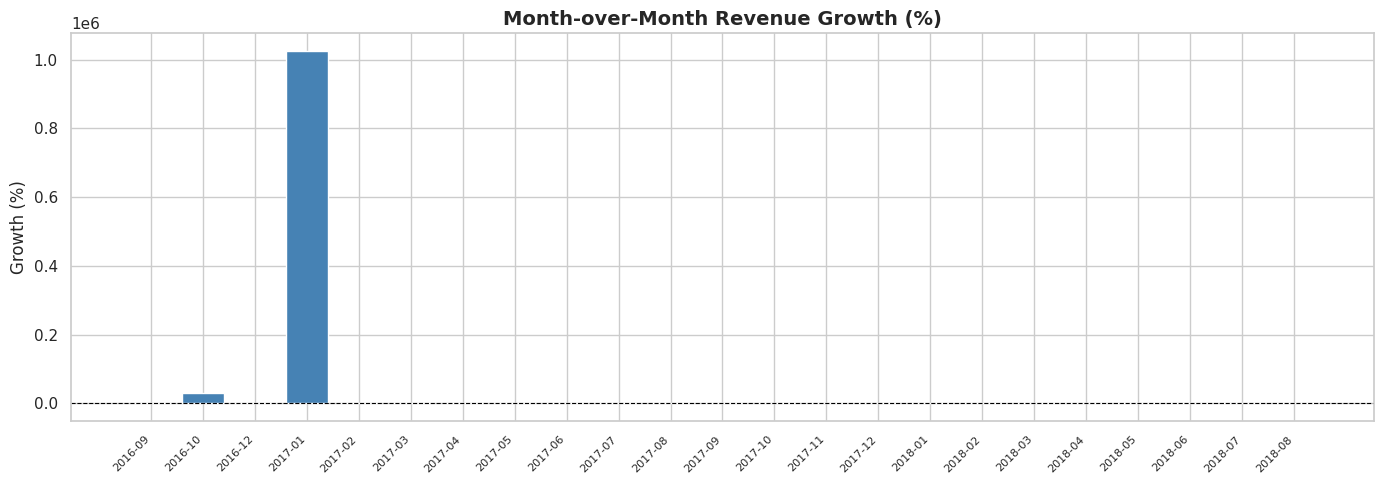

Best growth month : 2017-01 | 1025573.0%


In [24]:
mom = monthly.copy()
mom['mom_growth'] = mom['revenue'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if x >= 0 else 'salmon' for x in mom['mom_growth'].fillna(0)]
ax.bar(range(len(mom)), mom['mom_growth'].fillna(0), color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(mom)))
ax.set_xticklabels(mom['order_month'], rotation=45, ha='right', fontsize=8)
ax.set_title('Month-over-Month Revenue Growth (%)', fontweight='bold')
ax.set_ylabel('Growth (%)')
plt.tight_layout()
plt.savefig('mom_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print('Best growth month :', mom.loc[mom['mom_growth'].idxmax(), 'order_month'],
      f"| {mom['mom_growth'].max():.1f}%")

## Step 12 — Seasonal Demand & Payment Methods

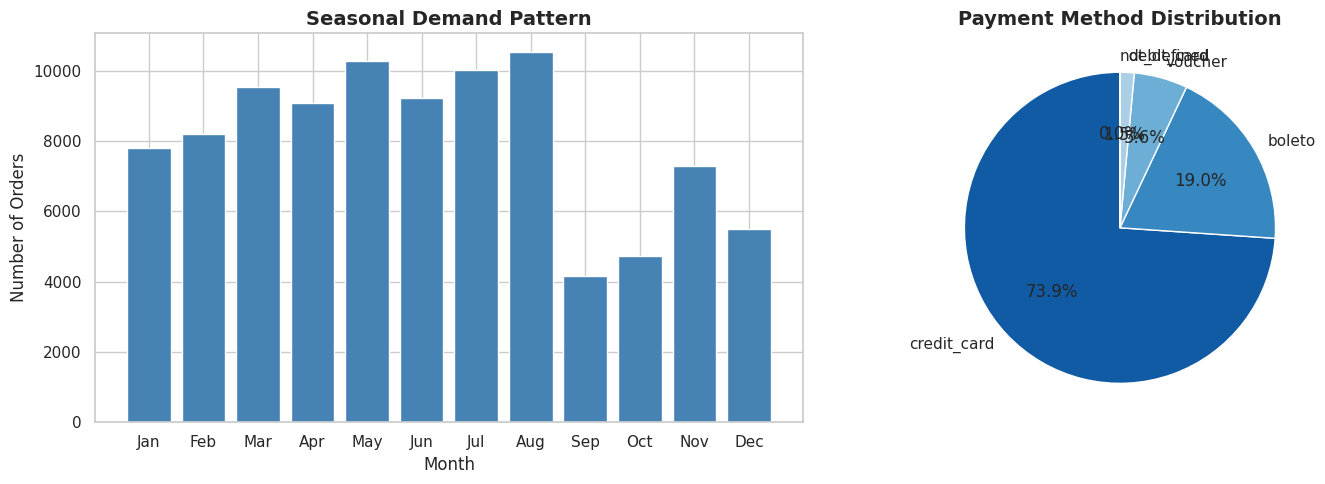

Payment Method Breakdown:
payment_type  transactions  pct
 credit_card         76795 73.9
      boleto         19784 19.0
     voucher          5775  5.6
  debit_card          1529  1.5
 not_defined             3  0.0


In [25]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = (df.groupby('order_month_num')['order_id']
              .nunique().reset_index()
              .rename(columns={'order_id':'orders'}))
seasonal['month_name'] = seasonal['order_month_num'].apply(lambda x: month_names[x-1])

pay_dist = (payments.groupby('payment_type')['payment_value']
                     .agg(['count','sum']).reset_index()
                     .rename(columns={'count':'transactions','sum':'value'}))
pay_dist['pct'] = (pay_dist['transactions'] / pay_dist['transactions'].sum() * 100).round(1)
pay_dist = pay_dist.sort_values('transactions', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(seasonal['month_name'], seasonal['orders'], color='steelblue')
axes[0].set_title('Seasonal Demand Pattern', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Orders')

axes[1].pie(pay_dist['transactions'], labels=pay_dist['payment_type'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Blues_r', len(pay_dist)),
            wedgeprops={'edgecolor':'white'})
axes[1].set_title('Payment Method Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('seasonal_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print('Payment Method Breakdown:')
print(pay_dist[['payment_type','transactions','pct']].to_string(index=False))

## Step 13 — Export Results for Tableau

In [26]:
# Export clean CSVs for Tableau dashboard
monthly.to_csv('export_monthly_revenue.csv', index=False)
cat_rev.to_csv('export_category_revenue.csv', index=False)
state_rev.to_csv('export_state_revenue.csv', index=False)
seg_summary.to_csv('export_rfm_segments.csv', index=False)
pay_dist.to_csv('export_payment_methods.csv', index=False)

print('Exported 5 CSV files for Tableau:')
print('  - export_monthly_revenue.csv')
print('  - export_category_revenue.csv')
print('  - export_state_revenue.csv')
print('  - export_rfm_segments.csv')
print('  - export_payment_methods.csv')

# Download all exports
from google.colab import files
for f in ['export_monthly_revenue.csv','export_category_revenue.csv',
          'export_state_revenue.csv','export_rfm_segments.csv',
          'export_payment_methods.csv']:
    files.download(f)

print('\nAll done! Upload these CSVs to Tableau Public to build your dashboard.')

Exported 5 CSV files for Tableau:
  - export_monthly_revenue.csv
  - export_category_revenue.csv
  - export_state_revenue.csv
  - export_rfm_segments.csv
  - export_payment_methods.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All done! Upload these CSVs to Tableau Public to build your dashboard.


## Key Insights Summary

| Insight | Finding |
|--------|--------|
| Top revenue state | Sao Paulo (SP) dominates |
| Peak demand month | November (Black Friday effect) |
| Top payment method | Credit Card (~73% of transactions) |
| Repeat purchase rate | ~3% (largely one-time buyers) |
| Top 3 categories | Health & Beauty, Watches, Bed/Bath |
| Top 3 revenue share | ~68% of total sales |
